<a href="https://colab.research.google.com/github/xinliwvu/MTF/blob/main/Urysohn_Machine_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 The Urysohn Machine
### MTF-Inspired Continual Learning with Structural Decoupling

This notebook implements the **Urysohn Machine** — a neural architecture derived from the
Metric-Topological Factorization (MTF) theory of hippocampal-neocortical dialogue.

**Core idea:** Catastrophic forgetting in continual learning is not an optimization failure —
it is an *architectural* one. The solution is to structurally decouple two problems that
current ML conflates:

- **The Indexing Problem** (Σ): Discover which *topological regime* an input belongs to
- **The Metric Problem** (G_c): Learn task geometry *within* that regime

**Named after** Pavel Urysohn (1898–1924), whose lemma guarantees topological separation
is achievable before the machine attempts to find it.

**Architecture components:**
| Component | Role | Objective |
|-----------|------|-----------|
| `TopologicalIndexer` Σ | Maps inputs → context distribution | L_top (separation + coherence + sparsity) |
| `MetricLearnerPool` {G_c} | Per-context task networks | L_metric (task + contractivity) |
| `IdentificationProcedure` ID | Diagnoses remapping cause | Composite test (density → dim → TDA) |
| `FeedbackController` | Closes the loop: ID → Σ | Gated update with diagnosis branching |

**Critical invariant:** Task loss *never* flows into θ_Σ. This is enforced structurally.


## 0. Setup

In [ ]:
# Install dependencies
!pip install torch torchvision scikit-learn --quiet

# Optional: persistent homology (upgrades the identification procedure)
# !pip install ripser --quiet


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import json
import time
import copy
from dataclasses import dataclass, field
from typing import Optional
from collections import defaultdict, deque
from enum import Enum, auto

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected — training will be slower but still functional.")


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Topological Indexer (Σ)

**Theory:** The indexer solves the *topological* partition problem, not the task problem.
Its objective is:

$$\mathcal{L}_{top} = -\lambda_1 \cdot \text{Sep}(\Sigma) + \lambda_2 \cdot \text{Coh}(\Sigma) + \lambda_3 \cdot \text{Sparse}(\Sigma)$$

Task loss `L_task` does **not** appear here — by design.

The `ContextHead` uses learnable prototypes in feature space. Each input is assigned to
the nearest prototype (in a learned metric), with Gumbel-softmax for differentiability
during training and argmax at inference.

**Stability gating:** Established contexts resist boundary adjustment via:
$$w_\emptyset(c, t) = \exp(-\gamma \cdot T_{stable}(c))$$


In [ ]:
@dataclass
class IndexerConfig:
    input_dim: int = 784
    hidden_dim: int = 256
    feature_dim: int = 64
    max_contexts: int = 20
    init_contexts: int = 2
    sparsity_weight: float = 1.0
    separation_weight: float = 2.0
    coherence_weight: float = 1.0
    stability_decay: float = 0.005
    post_split_lr_scale: float = 3.0
    post_split_steps: int = 300


class TopologicalFeatureMap(nn.Module):
    """φ: X → R^m — topology-preserving feature map preceding the indexer."""
    def __init__(self, input_dim, feature_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, feature_dim),
        )
    def forward(self, x):
        if x.dim() > 2: x = x.view(x.size(0), -1)
        return self.net(x)


class ContextHead(nn.Module):
    """Maps features → context assignment logits via learnable prototypes."""
    def __init__(self, feature_dim, max_contexts):
        super().__init__()
        self.prototypes = nn.Parameter(torch.randn(max_contexts, feature_dim) * 0.1)
        self.log_temp = nn.Parameter(torch.zeros(max_contexts))

    def forward(self, features, active_contexts, tau=0.5):
        active_protos = self.prototypes[active_contexts]
        temps = self.log_temp[active_contexts].exp()
        diffs = features.unsqueeze(1) - active_protos.unsqueeze(0)
        sq_dists = (diffs ** 2).sum(-1)
        logits = -sq_dists / (temps.unsqueeze(0) + 1e-6)
        soft = F.gumbel_softmax(logits, tau=tau, hard=False)
        hard = F.gumbel_softmax(logits, tau=tau, hard=True)
        return soft, hard


class TopologicalIndexer(nn.Module):
    """
    Σ: X → Δ(C)

    INVARIANT: task loss never enters this module's gradient graph.
    Trained exclusively on L_top.
    """
    def __init__(self, config: IndexerConfig):
        super().__init__()
        self.config = config
        self.feature_map = TopologicalFeatureMap(config.input_dim, config.feature_dim, config.hidden_dim)
        self.context_head = ContextHead(config.feature_dim, config.max_contexts)
        self.register_buffer("active_contexts", torch.zeros(config.max_contexts, dtype=torch.bool))
        self.active_contexts[:config.init_contexts] = True
        self.register_buffer("stability_counts", torch.zeros(config.max_contexts, dtype=torch.long))
        self.register_buffer("post_split_remaining", torch.zeros(config.max_contexts, dtype=torch.long))
        self.context_birth_step = {i: 0 for i in range(config.init_contexts)}
        self.global_step = 0

    @property
    def n_active_contexts(self): return self.active_contexts.sum().item()

    @property
    def active_indices(self): return self.active_contexts.nonzero(as_tuple=True)[0].tolist()

    def forward(self, x, hard=False, tau=0.5):
        features = self.feature_map(x)
        soft, hard_assign = self.context_head(features, self.active_contexts, tau=tau)
        context_indices = hard_assign.argmax(dim=-1)
        active_idx = torch.tensor(self.active_indices, device=x.device)
        global_context_indices = active_idx[context_indices]
        return {"features": features, "soft": soft, "hard": hard_assign,
                "context_idx": global_context_indices}

    def topological_loss(self, features, soft_assignments):
        """L_top = -λ1·Sep + λ2·Coh + λ3·Sparse"""
        cfg = self.config
        K = soft_assignments.shape[1]
        eps = 1e-8

        # Centroids: μ_c = E[φ(x)|c]
        weights = soft_assignments.T
        weight_sums = weights.sum(dim=1, keepdim=True).clamp(min=eps)
        centroids = (weights @ features) / weight_sums

        # Separation: maximize distance between centroids
        centroid_diffs = centroids.unsqueeze(0) - centroids.unsqueeze(1)
        centroid_dists = (centroid_diffs ** 2).sum(-1)
        mask = ~torch.eye(K, dtype=torch.bool, device=features.device)
        separation = centroid_dists[mask].mean() if mask.sum() > 0 else torch.tensor(0.0, device=features.device)

        # Coherence: minimize within-context variance
        diffs = features.unsqueeze(1) - centroids.unsqueeze(0)
        sq_dists = (diffs ** 2).sum(-1)
        coherence = ((soft_assignments * sq_dists).sum(0) / weight_sums.squeeze(1).clamp(min=eps)).mean()

        # Sparsity: minimize assignment entropy
        sparsity = -(soft_assignments * (soft_assignments + eps).log()).sum(-1).mean()

        total = -cfg.separation_weight * separation + cfg.coherence_weight * coherence + cfg.sparsity_weight * sparsity
        return {"total": total, "separation": separation, "coherence": coherence, "sparsity": sparsity}

    def stability_gating(self):
        """w_∅(c,t) = exp(-γ·T_stable(c)). Post-split contexts get elevated plasticity."""
        weights = torch.ones(self.config.max_contexts, device=self.active_contexts.device)
        stable = (self.stability_counts > 0) & self.active_contexts
        weights[stable] = torch.exp(-self.config.stability_decay * self.stability_counts[stable].float())
        post = (self.post_split_remaining > 0) & self.active_contexts
        weights[post] = self.config.post_split_lr_scale
        return weights

    def update_stability(self, remapping_events):
        for c in self.active_indices:
            if remapping_events.get(c, False): self.stability_counts[c] = 0
            else: self.stability_counts[c] += 1
            if self.post_split_remaining[c] > 0: self.post_split_remaining[c] -= 1

    def split_context(self, context_idx, persistence=1.0):
        inactive = (~self.active_contexts).nonzero(as_tuple=True)[0]
        if len(inactive) == 0:
            raise RuntimeError(f"All {self.config.max_contexts} context slots in use.")
        new_idx = inactive[0].item()
        self.active_contexts[new_idx] = True
        self.stability_counts[new_idx] = 0
        self.context_birth_step[new_idx] = self.global_step
        with torch.no_grad():
            old_proto = self.context_head.prototypes[context_idx].clone()
            noise = torch.randn_like(old_proto) * (0.1 / (persistence + 1e-6))
            self.context_head.prototypes[new_idx] = old_proto + noise
            self.context_head.log_temp[new_idx] = self.context_head.log_temp[context_idx].clone()
        self.post_split_remaining[context_idx] = self.config.post_split_steps
        self.post_split_remaining[new_idx] = self.config.post_split_steps
        self.stability_counts[context_idx] = 0
        return new_idx

    def merge_contexts(self, context_a, context_b):
        with torch.no_grad():
            self.context_head.prototypes[context_a] = (
                self.context_head.prototypes[context_a] + self.context_head.prototypes[context_b]) / 2
        self.active_contexts[context_b] = False
        self.stability_counts[context_b] = 0

    def increment_step(self): self.global_step += 1

    def state_summary(self):
        lines = [f"TopologicalIndexer @ step {self.global_step}",
                 f"  Active contexts: {self.n_active_contexts}"]
        for c in self.active_indices:
            lines.append(f"  Context {c:2d}: stability={self.stability_counts[c].item():4d}, "
                         f"post_split={self.post_split_remaining[c].item():3d}")
        return "\n".join(lines)


print("✓ TopologicalIndexer defined")


✓ TopologicalIndexer defined


## 2. Metric Learner Pool ({G_c})

Each context gets its own metric learner with two objectives:

$$\mathcal{L}_{metric}(G_c | \Sigma) = \mathcal{L}_{task}(G_c) + \gamma \cdot \mathcal{R}_{contract}(G_c)$$

The **contractivity regularizer** penalizes pairs where the encoder is expansive:
$$\mathcal{R}_{contract} = \mathbb{E}\left[\max\left(0, \frac{\|G_c(x) - G_c(x')\|}{\|x - x'\|} - \kappa\right)\right]$$

This forces $\mathcal{Z}_c$ to be bowl-shaped (contractible) — the geometric condition
that guarantees a unique attractor and eliminates saddle-type obstructions (Conjecture 2).


In [ ]:
@dataclass
class MetricLearnerConfig:
    input_dim: int = 784
    hidden_dim: int = 256
    output_dim: int = 2           # 2 for Split-MNIST binary tasks
    latent_dim: int = 128
    contractivity_weight: float = 0.01
    contractivity_kappa: float = 0.9
    n_contractivity_pairs: int = 32
    dropout: float = 0.1


class SingleMetricLearner(nn.Module):
    """G_c: X → Z_c → output. One per context."""
    def __init__(self, config: MetricLearnerConfig):
        super().__init__()
        self.config = config
        self.encoder = nn.Sequential(
            nn.Linear(config.input_dim, config.hidden_dim), nn.LayerNorm(config.hidden_dim),
            nn.GELU(), nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.hidden_dim), nn.LayerNorm(config.hidden_dim),
            nn.GELU(), nn.Linear(config.hidden_dim, config.latent_dim),
        )
        self.task_head = nn.Sequential(nn.LayerNorm(config.latent_dim),
                                       nn.Linear(config.latent_dim, config.output_dim))

    def encode(self, x):
        if x.dim() > 2: x = x.view(x.size(0), -1)
        return self.encoder(x)

    def forward(self, x):
        if x.dim() > 2: x = x.view(x.size(0), -1)
        z = self.encoder(x)
        return {"z": z, "logits": self.task_head(z)}

    def contractivity_loss(self, x, z):
        """R_contract: penalize expansive mappings (Lipschitz ratio > κ)."""
        B = x.size(0)
        if B < 2: return torch.tensor(0.0, device=x.device)
        n = min(self.config.n_contractivity_pairs, B * (B - 1) // 2)
        ia = torch.randint(0, B, (n,), device=x.device)
        ib = torch.randint(0, B, (n,), device=x.device)
        valid = ia != ib
        if valid.sum() == 0: return torch.tensor(0.0, device=x.device)
        ia, ib = ia[valid], ib[valid]
        xf = x.view(B, -1) if x.dim() > 2 else x
        dx = (xf[ia] - xf[ib]).norm(dim=-1)
        dz = (z[ia] - z[ib]).norm(dim=-1)
        return F.relu(dz / (dx + 1e-8) - self.config.contractivity_kappa).mean()

    def metric_loss(self, x, targets):
        out = self.forward(x)
        l_task = F.cross_entropy(out["logits"], targets)
        l_c = self.contractivity_loss(x, out["z"])
        return {"total": l_task + self.config.contractivity_weight * l_c,
                "task": l_task, "contractivity": l_c,
                "logits": out["logits"], "z": out["z"]}


class MetricLearnerPool(nn.Module):
    """Dynamic collection of per-context metric learners."""
    def __init__(self, config: MetricLearnerConfig, init_contexts: int = 2):
        super().__init__()
        self.config = config
        self.learners = nn.ModuleDict()
        for i in range(init_contexts): self._create(i)

    def _create(self, idx, clone_from=None):
        key = str(idx)
        if clone_from is not None and str(clone_from) in self.learners:
            new = copy.deepcopy(self.learners[str(clone_from)])
            with torch.no_grad():
                for p in new.parameters(): p.add_(torch.randn_like(p) * 0.01)
            self.learners[key] = new
        else:
            self.learners[key] = SingleMetricLearner(self.config)

    def get(self, idx) -> SingleMetricLearner:
        return self.learners[str(idx)]

    def forward(self, x, context_indices):
        B = x.size(0)
        logits = torch.zeros(B, self.config.output_dim, device=x.device)
        z = torch.zeros(B, self.config.latent_dim, device=x.device)
        for c in context_indices.unique():
            c = c.item()
            mask = context_indices == c
            if str(c) not in self.learners: continue
            out = self.get(c)(x[mask])
            logits[mask], z[mask] = out["logits"], out["z"]
        return {"logits": logits, "z": z}

    def compute_losses(self, x, targets, context_indices):
        per_ctx = {}
        all_logits = torch.zeros(x.size(0), self.config.output_dim, device=x.device)
        for c in context_indices.unique():
            c = c.item()
            mask = context_indices == c
            if mask.sum() == 0 or str(c) not in self.learners: continue
            losses = self.get(c).metric_loss(x[mask], targets[mask])
            per_ctx[c] = losses
            all_logits[mask] = losses["logits"]
        return {"per_context": per_ctx, "all_logits": all_logits}

    def add_context(self, new_idx, parent_idx=None): self._create(new_idx, clone_from=parent_idx)
    def remove_context(self, idx):
        key = str(idx)
        if key in self.learners:
            del self.learners[key]

    def sliced_wasserstein(self, ca, cb, xa, xb, n_proj=50):
        """Approximate Wasserstein distance for merge criterion."""
        if xa is None or xb is None: return float("inf")
        with torch.no_grad():
            za = self.get(ca).encode(xa)
            zb = self.get(cb).encode(xb)
        d = za.size(1)
        projs = F.normalize(torch.randn(d, n_proj, device=za.device), dim=0)
        pa = (za @ projs).sort(0)[0][:min(za.size(0), zb.size(0))]
        pb = (zb @ projs).sort(0)[0][:min(za.size(0), zb.size(0))]
        return (pa - pb).abs().mean().item()


print("✓ MetricLearnerPool defined")


✓ MetricLearnerPool defined


## 3. Identification Procedure (ID)

This is the theoretical heart. The identification procedure diagnoses *why*
remapping events are occurring via a composite test:

| Test | Cost | Detects |
|------|------|---------|
| Density correlation | Cheap | H_M_data (low-density failure) |
| Intrinsic dimension (TwoNN) | Medium | H_T (codim-1) vs H_M_cap (volumetric) |
| Temporal persistence filter | Medium | Transient vs genuine frustration |
| Persistent homology (ripser) | Expensive | H_T confirmation via PH_k(R_c) |

**Key result (Remapping Homology Theorem — conjectured):**
Under H_T, the topology of the remapping point cloud mirrors the homology of M_c:
$$\beta_k(\text{Rips}(\mathcal{R}_c, \epsilon)) \approx \beta_k(\mathcal{M}_c)$$

**Saddle detection condition:**
$$R(x) = \mathbf{1}[\epsilon(x) > \epsilon^*] \wedge \mathbf{1}[\|\nabla_z \mathcal{L}_{task}\|^2 < \delta]$$


In [ ]:
class Diagnosis(Enum):
    NONE = auto()
    TOPOLOGICAL = auto()
    CAPACITY = auto()
    DATA = auto()
    SHIFT = auto()

@dataclass
class DiagnosisResult:
    diagnosis: Diagnosis
    confidence: float = 0.0
    estimated_boundary: Optional[torch.Tensor] = None
    persistence: float = 1.0
    estimated_degree: int = 1
    context_idx: int = -1
    metadata: dict = field(default_factory=dict)

@dataclass
class IdentificationConfig:
    loss_threshold: float = 0.5
    grad_norm_threshold: float = 0.5
    min_remapping_volume: int = 10
    persistence_window: int = 60
    persistence_rate: float = 0.10
    density_correlation_threshold: float = 0.3
    intrinsic_dim_tolerance: float = 0.5
    use_tda: bool = False
    min_persistence: float = 0.1
    tda_max_points: int = 200


class RemappingBuffer:
    def __init__(self, window=60):
        self.window = window
        self.events = deque(maxlen=window * 100)
        self.step_history = deque(maxlen=window)

    def add(self, x_remap, step):
        for xi in x_remap: self.events.append((xi.detach().cpu(), step))
        self.step_history.append((step, len(x_remap)))

    def recent(self, step): return [x for x, s in self.events if s >= step - self.window]

    def persistence_score(self, step):
        recent = [c for s, c in self.step_history if s >= step - self.window]
        return sum(1 for c in recent if c > 0) / len(recent) if recent else 0.0

    def volume(self, step): return len(self.recent(step))

    def as_tensor(self, step):
        ev = self.recent(step)
        return torch.stack(ev) if ev else None


class IdentificationProcedure:
    def __init__(self, config: IdentificationConfig):
        self.config = config
        self.buffers: dict[int, RemappingBuffer] = {}
        self.context_stats: dict[int, dict] = {}

    def add_context(self, idx):
        self.buffers[idx] = RemappingBuffer(self.config.persistence_window)
        self.context_stats[idx] = {"n": 0, "mean": None, "var": None}

    def remove_context(self, idx):
        self.buffers.pop(idx, None); self.context_stats.pop(idx, None)

    def detect_remapping(self, loss_per_sample, grad_norm_proxy):
        """R(x) = 1[ε > ε*] OR 1[||∇|| < δ].

        Original used AND — requiring high loss AND high confidence (saddle).
        BUG: new-task data has high loss but LOW confidence (uncertain),
        so the AND gate blocks detection. No remapping → no splits →
        purity drops monotonically.

        Fix: use OR. High loss alone signals wrong context.
        High confidence + moderate loss signals a saddle point.
        Either condition warrants investigation.
        """
        high_loss = loss_per_sample > self.config.loss_threshold
        saddle_signature = grad_norm_proxy < self.config.grad_norm_threshold
        return high_loss | saddle_signature

    def accumulate(self, idx, x_remap, step):
        if idx in self.buffers and x_remap.numel() > 0:
            self.buffers[idx].add(x_remap, step)

    def update_stats(self, idx, x):
        x_flat = x.view(x.size(0), -1).float().cpu()
        if idx not in self.context_stats:
            self.context_stats[idx] = {"n": 0, "mean": None, "var": None}
        s = self.context_stats[idx]
        n_new, n_old = x_flat.size(0), s["n"]
        n_total = n_old + n_new
        if n_old == 0:
            s["mean"] = x_flat.mean(0); s["var"] = x_flat.var(0).clamp(min=1e-8)
        else:
            new_mean = x_flat.mean(0)
            delta = new_mean - s["mean"]
            s["mean"] = s["mean"] + delta * n_new / n_total
            s["var"] = (s["var"] * n_old + x_flat.var(0) * n_new) / n_total + delta**2 * n_old * n_new / n_total**2
        s["n"] = n_total

    def diagnose(self, context_idx, step, ambient_dim=None) -> DiagnosisResult:
        buf = self.buffers.get(context_idx)
        if buf is None: return DiagnosisResult(Diagnosis.NONE, context_idx=context_idx)

        # Step 1: Volume
        vol = buf.volume(step)
        if vol < self.config.min_remapping_volume:
            return DiagnosisResult(Diagnosis.NONE, context_idx=context_idx,
                                   metadata={"reason": "low_volume", "vol": vol})

        rt = buf.as_tensor(step)
        if rt is None: return DiagnosisResult(Diagnosis.NONE, context_idx=context_idx)

        # Step 2: Temporal persistence
        pers = buf.persistence_score(step)
        if pers < self.config.persistence_rate:
            return DiagnosisResult(Diagnosis.NONE, context_idx=context_idx,
                                   metadata={"reason": "not_persistent", "pers": pers})

        # Step 3: Density correlation → H_M_data
        dc = self._density_corr(context_idx, rt)
        if abs(dc) > self.config.density_correlation_threshold:
            return DiagnosisResult(Diagnosis.DATA, confidence=abs(dc), context_idx=context_idx,
                                   metadata={"density_corr": dc})

        # Step 4: Intrinsic dimension → H_T vs H_M_cap
        n_amb = ambient_dim or rt.size(1)
        idim, idim_conf = self._intrinsic_dim(rt)
        if idim >= n_amb - 1 - self.config.intrinsic_dim_tolerance:
            return DiagnosisResult(Diagnosis.CAPACITY, confidence=idim_conf, context_idx=context_idx,
                                   metadata={"intrinsic_dim": idim, "ambient": n_amb})

        # Tentative H_T
        boundary = rt.float().mean(0, keepdim=True)
        tda_conf = 0.5
        if self.config.use_tda and rt.size(0) >= 10:
            tda_conf = self._tda(rt).get("confidence", 0.5)

        return DiagnosisResult(
            Diagnosis.TOPOLOGICAL,
            confidence=min(idim_conf, pers) * (1 + tda_conf) / 2,
            estimated_boundary=boundary, persistence=pers,
            context_idx=context_idx,
            metadata={"idim": idim, "pers": pers, "vol": vol, "tda_conf": tda_conf})

    def _density_corr(self, idx, rt):
        s = self.context_stats.get(idx, {})
        if s.get("n", 0) < 10 or s.get("mean") is None: return 0.0
        x = rt.float().cpu()
        if x.shape[1] != s["mean"].shape[0]: return 0.0
        sq = ((x - s["mean"]) ** 2 / s["var"].clamp(1e-8)).sum(1)
        ctx_scale = s["var"].sum().item()
        if ctx_scale < 1e-8: return 0.0
        ratio = sq.mean().item() / ctx_scale
        return min(1.0, max(-1.0, (ratio - 1) / (ratio + 1)))

    def _intrinsic_dim(self, x):
        x_np = x.float().cpu().numpy()
        N = x_np.shape[0]
        if N < 6: return float(x_np.shape[1]), 0.0
        if N > 500: x_np = x_np[np.random.choice(N, 500, replace=False)]
        try:
            from sklearn.neighbors import NearestNeighbors
            k = min(6, x_np.shape[0] - 1)
            d, _ = NearestNeighbors(n_neighbors=k).fit(x_np).kneighbors(x_np)
            r1, r2 = d[:, 1], d[:, min(2, d.shape[1]-1)]
            valid = (r1 > 1e-10) & (r2 > r1)
            if valid.sum() < 5: return float(x_np.shape[1] // 2), 0.2
            mu = r2[valid] / r1[valid]
            idim = float(np.clip(1.0 / np.log(mu).mean(), 1.0, x_np.shape[1]))
            return idim, float(np.exp(-np.var(np.log(mu))))
        except Exception:
            return float(x_np.shape[1] // 2), 0.3

    def _tda(self, x):
        x_np = x.float().cpu().numpy()
        if x_np.shape[0] > self.config.tda_max_points:
            x_np = x_np[np.random.choice(x_np.shape[0], self.config.tda_max_points, replace=False)]
        try:
            import ripser
            dgms = ripser.ripser(x_np, maxdim=1)["dgms"]
            h1 = dgms[1] if len(dgms) > 1 else np.array([]).reshape(0, 2)
            if len(h1) == 0: return {"confidence": 0.3}
            lt = h1[:, 1] - h1[:, 0]
            lt = lt[np.isfinite(lt)]
            n_pers = (lt > self.config.min_persistence).sum()
            return {"confidence": float(min(1.0, n_pers / 2.0)), "n_persistent": int(n_pers)}
        except ImportError:
            return {"confidence": 0.4}


print("✓ IdentificationProcedure defined")


✓ IdentificationProcedure defined


## 4. Feedback Controller

Closes the loop: **ID → Σ** (Interface 3).

The unified update equation:
$$\Delta\theta_\Sigma = -\eta_\Sigma(t) \cdot \nabla_{\theta_\Sigma}\hat{\mathcal{T}}(\Sigma) \cdot W(D, t) + \Phi(D, \hat{\mathcal{B}})$$

Branching on diagnosis type:

| Diagnosis | Indexer update | Other action |
|-----------|---------------|--------------|
| ∅ | Stability-damped gradient | None |
| H_M_data | **None** | Request more data |
| H_M_cap | **None** | Request capacity expansion |
| H_M_shift | Boundary correction | None |
| H_T | **Split operation** | Clone metric learner |

**Merge hysteresis:** Each split-merge cycle reduces the merge threshold,
preventing oscillation: $\tau^{(n)} = \tau^{(0)} \cdot \alpha^n$


In [ ]:
@dataclass
class FeedbackConfig:
    merge_threshold: float = 0.3
    merge_hysteresis: float = 0.5
    min_steps_before_merge: int = 500
    min_confidence: float = 0.2
    max_splits_per_step: int = 1
    verbose: bool = True


class FeedbackController:
    """
    Translates ID diagnosis → indexer + metric pool updates.
    INVARIANT: task_loss never enters this controller.
    """
    def __init__(self, config, indexer, metric_pool):
        self.config = config
        self.indexer = indexer
        self.metric_pool = metric_pool
        self.split_merge_history: dict[tuple, int] = {}
        self.context_age: dict[int, int] = {}
        self.global_step = 0
        self._splits_this_step = 0
        self.pending_requests = []

    def reset_step(self):
        self._splits_this_step = 0
        self.global_step += 1
        for c in self.context_age: self.context_age[c] = self.context_age.get(c, 0) + 1

    def register_context(self, idx): self.context_age[idx] = 0

    def apply(self, diag: DiagnosisResult, id_proc) -> dict:
        d, c = diag.diagnosis, diag.context_idx
        log = {"context": c, "diagnosis": d.name, "action": "none", "new_context": None}

        if d == Diagnosis.NONE:
            log["action"] = "stability_preserved"
        elif d == Diagnosis.DATA:
            self.pending_requests.append({"type": "sampling", "context": c})
            log["action"] = "sampling_requested"
            if self.config.verbose: print(f"  [ID→Σ] ctx {c}: H_M_data (conf={diag.confidence:.2f})")
        elif d == Diagnosis.CAPACITY:
            self.pending_requests.append({"type": "capacity", "context": c})
            log["action"] = "capacity_requested"
            if self.config.verbose: print(f"  [ID→Σ] ctx {c}: H_M_cap (conf={diag.confidence:.2f})")
        elif d == Diagnosis.TOPOLOGICAL:
            if diag.confidence < self.config.min_confidence:
                log["action"] = "h_t_low_confidence"
            elif self._splits_this_step >= self.config.max_splits_per_step:
                log["action"] = "split_throttled"
            else:
                new_idx = self._split(c, diag, id_proc)
                log["action"] = "split_executed"
                log["new_context"] = new_idx
                self._splits_this_step += 1
                print(f"  *** [ID→Σ] SPLIT: ctx {c} → ctx {new_idx} "
                      f"(conf={diag.confidence:.2f}, pers={diag.persistence:.2f}, "
                      f"K={self.indexer.n_active_contexts}) ***")
        return log

    def _split(self, ctx_idx, diag, id_proc):
        new_idx = self.indexer.split_context(ctx_idx, persistence=diag.persistence)
        self.metric_pool.add_context(new_idx, parent_idx=ctx_idx)
        id_proc.add_context(new_idx)
        self.register_context(new_idx)
        if ctx_idx in id_proc.buffers:
            id_proc.buffers[ctx_idx].events.clear()
            id_proc.buffers[ctx_idx].step_history.clear()
        return new_idx

    def check_merge(self, ca, cb, xa=None, xb=None):
        if min(self.context_age.get(ca, 0), self.context_age.get(cb, 0)) < self.config.min_steps_before_merge:
            return False
        if xa is None or xb is None or xa.size(0) < 5 or xb.size(0) < 5: return False
        dw = self.metric_pool.sliced_wasserstein(ca, cb, xa, xb)
        key = (min(ca, cb), max(ca, cb))
        n = self.split_merge_history.get(key, 0)
        threshold = self.config.merge_threshold * (self.config.merge_hysteresis ** n)
        return dw < threshold

    def merge(self, ca, cb, id_proc):
        key = (min(ca, cb), max(ca, cb))
        self.split_merge_history[key] = self.split_merge_history.get(key, 0) + 1
        self.indexer.merge_contexts(ca, cb)
        self.metric_pool.remove_context(cb)
        id_proc.remove_context(cb)
        self.context_age.pop(cb, None)
        if self.config.verbose: print(f"  [ID→Σ] MERGE: ctx {cb} → {ca}")


print("✓ FeedbackController defined")


✓ FeedbackController defined


## 5. Urysohn Machine (Full Architecture)

Implements the closed-loop dynamics:
$$\mathcal{S}(t+1) = \mathcal{F}(\mathcal{S}(t), x_{t+1})$$

**The three interfaces are enforced structurally in `step()`:**
1. **Σ → G_c**: Hard assignment via `torch.no_grad()` — non-differentiable
2. **G_c → ID**: Binary remapping signal — `L_task` values, not gradients
3. **ID → Σ**: Diagnosis with geometric payload — never raw task gradients

**Timescale separation:** `lr_metric << lr_indexer` is not just a hyperparameter —
it is required for the stability filter to function correctly.


In [ ]:
@dataclass
class UrysohnConfig:
    indexer: IndexerConfig = field(default_factory=IndexerConfig)
    metric: MetricLearnerConfig = field(default_factory=MetricLearnerConfig)
    identification: IdentificationConfig = field(default_factory=IdentificationConfig)
    feedback: FeedbackConfig = field(default_factory=FeedbackConfig)
    lr_indexer: float = 1e-3   # η_Σ: fast timescale
    lr_metric: float = 1e-4    # η_G: slow timescale (10x separation)
    weight_decay: float = 1e-4
    id_check_interval: int = 50
    merge_check_interval: int = 300
    context_buffer_size: int = 256
    grad_clip: float = 1.0


class UrysohnMachine(nn.Module):
    def __init__(self, config: UrysohnConfig):
        super().__init__()
        self.config = config
        self.indexer = TopologicalIndexer(config.indexer)
        self.metric_pool = MetricLearnerPool(config.metric, init_contexts=config.indexer.init_contexts)
        self.id_proc = IdentificationProcedure(config.identification)
        self.feedback = FeedbackController(config.feedback, self.indexer, self.metric_pool)
        for c in self.indexer.active_indices:
            self.id_proc.add_context(c); self.feedback.register_context(c)
        self.ctx_buffers: dict[int, deque] = defaultdict(lambda: deque(maxlen=config.context_buffer_size))
        self._step = 0

    def build_optimizers(self):
        return {
            "indexer": optim.Adam(self.indexer.parameters(), lr=self.config.lr_indexer, weight_decay=self.config.weight_decay),
            "metric":  optim.Adam(self.metric_pool.parameters(), lr=self.config.lr_metric, weight_decay=self.config.weight_decay),
        }

    def forward(self, x):
        with torch.no_grad():
            idx_out = self.indexer(x, hard=True)
            routed = self.metric_pool.forward(x, idx_out["context_idx"])
        return {"logits": routed["logits"], "context_idx": idx_out["context_idx"]}

    def step(self, x, targets, optimizers):
        self.feedback.reset_step(); self.indexer.increment_step()
        tau = max(0.1, 1.0 - self._step * 1e-4)

        # ── Interface 1: Σ → G_c (non-differentiable routing) ──────────────
        idx_soft = self.indexer(x, hard=False, tau=tau)
        with torch.no_grad():
            idx_hard = self.indexer(x, hard=True)
            ctx_idx = idx_hard["context_idx"]   # [B] — no gradient

        # ── Metric learner forward ──────────────────────────────────────────
        m_results = self.metric_pool.compute_losses(x, targets, ctx_idx)

        # ── Interface 2: G_c → ID (remapping signal) ───────────────────────
        per_loss, grad_proxy = self._saddle_signals(ctx_idx, m_results)
        remap_mask = self.id_proc.detect_remapping(per_loss, grad_proxy)

        # ── Update metric learner (task + contractivity) ────────────────────
        m_total = sum(v["total"] for v in m_results["per_context"].values()) if m_results["per_context"] else torch.tensor(0.0)
        if m_results["per_context"]:
            optimizers["metric"].zero_grad()
            m_total.backward()
            nn.utils.clip_grad_norm_(self.metric_pool.parameters(), self.config.grad_clip)
            optimizers["metric"].step()

        # ── Update indexer (L_top only — ZERO task gradient) ────────────────
        topo = self.indexer.topological_loss(
            idx_soft["features"],  # NOT detached — feature map needs gradients from L_top
            idx_soft["soft"],
        )
        gate = self.indexer.stability_gating()[self.indexer.active_contexts].mean()
        optimizers["indexer"].zero_grad()
        (topo["total"] * gate).backward()
        nn.utils.clip_grad_norm_(self.indexer.parameters(), self.config.grad_clip)
        optimizers["indexer"].step()

        # ── Accumulate remapping events + update stability ──────────────────
        remap_per_ctx = {}
        for c in self.indexer.active_indices:
            mask_c = (ctx_idx == c) & remap_mask
            remap_per_ctx[c] = mask_c.sum().item() > 0
            if mask_c.sum() > 0: self.id_proc.accumulate(c, x[mask_c].detach(), self._step)
            mask_all = ctx_idx == c
            if mask_all.sum() > 0:
                self.id_proc.update_stats(c, x[mask_all].detach())
                for xi in x[mask_all].detach().cpu(): self.ctx_buffers[c].append(xi)
        self.indexer.update_stability(remap_per_ctx)

        # ── Interface 3: ID → Σ (periodic feedback) ─────────────────────────
        feedback_actions = []
        if self._step % self.config.id_check_interval == 0 and self._step > 0:
            for c in list(self.indexer.active_indices):
                diag = self.id_proc.diagnose(c, self._step, ambient_dim=x.view(x.size(0),-1).size(1))
                if diag.diagnosis != Diagnosis.NONE:
                    action = self.feedback.apply(diag, self.id_proc)
                    feedback_actions.append(action)
                    if action.get("new_context") is not None:
                        self._add_ctx_to_opt(action["new_context"], optimizers)

        if self._step % self.config.merge_check_interval == 0 and self._step > 0:
            self._check_merges(optimizers)

        metrics = {
            "step": self._step,
            "task_loss": sum(v["task"].item() for v in m_results["per_context"].values()) if m_results["per_context"] else 0.0,
            "topo_separation": topo["separation"].item(),
            "topo_loss": topo["total"].item(),
            "remap_rate": remap_mask.float().mean().item(),
            "n_contexts": self.indexer.n_active_contexts,
            "n_splits": sum(1 for a in feedback_actions if a["action"] == "split_executed"),
        }
        self._step += 1
        return metrics

    def _saddle_signals(self, ctx_idx, m_results):
        B = ctx_idx.size(0)
        per_loss = torch.zeros(B, device=ctx_idx.device)
        grad_proxy = torch.ones(B, device=ctx_idx.device)  # default: high → not a saddle
        for c, losses in m_results["per_context"].items():
            mask = ctx_idx == c
            per_loss[mask] = losses["task"].detach().expand(mask.sum())
            softmax_out = torch.softmax(losses["logits"].detach(), dim=-1)
            # Proxy: 1 - max_prob. Low confidence ≈ near saddle.
            grad_proxy[mask] = 1.0 - softmax_out.max(dim=-1).values
        return per_loss, grad_proxy

    def _add_ctx_to_opt(self, new_idx, optimizers):
        try:
            new_params = list(self.metric_pool.get(new_idx).parameters())
            optimizers["metric"].add_param_group({"params": new_params, "lr": self.config.lr_metric})
        except Exception: pass

    def _check_merges(self, optimizers):
        active = self.indexer.active_indices
        for i in range(len(active)):
            for j in range(i+1, len(active)):
                ca, cb = active[i], active[j]
                ba = list(self.ctx_buffers[ca])[-50:]; bb = list(self.ctx_buffers[cb])[-50:]
                if len(ba) < 10 or len(bb) < 10: continue
                dev = next(self.parameters()).device
                xa = torch.stack(ba).to(dev); xb = torch.stack(bb).to(dev)
                if self.feedback.check_merge(ca, cb, xa, xb):
                    self.feedback.merge(ca, cb, self.id_proc)
                    self.ctx_buffers.pop(cb, None); return

    def predict(self, x):
        with torch.no_grad(): return self.forward(x)["logits"].argmax(-1)

    def context_assignments(self, x):
        with torch.no_grad(): return self.indexer(x, hard=True)["context_idx"]


print("✓ UrysohnMachine defined")
print(f"\nAll components assembled. Full architecture ready.")


✓ UrysohnMachine defined

All components assembled. Full architecture ready.


## 6. Benchmark: Split-MNIST

5 sequential binary classification tasks (0/1, 2/3, 4/5, 6/7, 8/9).

**The ground truth partition is K*=5 contexts.**
Task identity is *never* given to the model — the Urysohn Machine must discover
the partition autonomously from input statistics and remapping signals.

**What to watch:**
- `n_contexts`: should grow in discrete jumps toward 5
- `topo_separation`: should increase as contexts diverge
- `remap_rate`: should decrease within contexts as metric learners converge
- Context purity → 1.0 (each context dominated by one task)


In [ ]:
class SplitMNIST(Dataset):
    TASK_CLASSES = [(0,1),(2,3),(4,5),(6,7),(8,9)]

    def __init__(self, data_dir="./data", train=True, task_id=None):
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,),(0.3081,)),
            transforms.Lambda(lambda x: x.view(-1)),
        ])
        self.base = torchvision.datasets.MNIST(data_dir, train=train, download=True, transform=transform)
        targets = torch.tensor(self.base.targets)
        self.task_id = task_id
        if task_id is not None:
            c0, c1 = self.TASK_CLASSES[task_id]
            self.indices = torch.where((targets==c0)|(targets==c1))[0].tolist()
            self.label_map = {c0: 0, c1: 1}
        else:
            raise ValueError("Use task_id= to get a specific task")

    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        x, y = self.base[self.indices[i]]
        return x, torch.tensor(self.label_map[int(y)], dtype=torch.long), self.task_id


def build_loaders(data_dir="./data", batch_size=64, n_tasks=5):
    tr, te = [], []
    for t in range(n_tasks):
        tr.append(DataLoader(SplitMNIST(data_dir, True, t), batch_size=batch_size, shuffle=True))
        te.append(DataLoader(SplitMNIST(data_dir, False, t), batch_size=batch_size, shuffle=False))
    return tr, te


def context_purity(machine, test_loaders, n_tasks, dev):
    ctxs, tasks = [], []
    for t in range(n_tasks):
        for x, y, _ in test_loaders[t]:
            ctxs.append(machine.context_assignments(x.to(dev)).cpu())
            tasks.append(torch.full((len(x),), t, dtype=torch.long))
    ctxs = torch.cat(ctxs); tasks = torch.cat(tasks)
    purities = {}
    for c in ctxs.unique():
        c = c.item(); mask = ctxs == c
        counts = torch.bincount(tasks[mask], minlength=n_tasks)
        purities[c] = (counts.max().float() / mask.sum().float()).item()
    return np.mean(list(purities.values())), purities


def task_accuracy(machine, test_loaders, n_tasks_seen, dev):
    accs = {}
    for t in range(n_tasks_seen):
        correct = total = 0
        for x, y, _ in test_loaders[t]:
            x, y = x.to(dev), y.to(dev)
            correct += (machine.predict(x) == y).sum().item(); total += len(y)
        accs[t] = correct / total
    return accs


print("✓ Split-MNIST benchmark ready")
print("Downloading MNIST data...")
build_loaders()  # triggers download
print("✓ MNIST downloaded")


✓ Split-MNIST benchmark ready


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.92MB/s]
/tmp/ipykernel_427/2322416289.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(self.base.targets)


✓ MNIST downloaded


## 7. Configuration

Adjust hyperparameters here. Key design constraints:
- `lr_metric` must be << `lr_indexer` (timescale separation)
- `init_contexts` starts small — the machine grows its partition
- `use_tda=True` requires `!pip install ripser` and significantly improves
  the identification procedure's accuracy


In [ ]:
# ── Experiment settings ──────────────────────────────────────────────────────
N_TASKS          = 5       # Split-MNIST has 5 tasks
EPOCHS_PER_TASK  = 5       # Training epochs per task
BATCH_SIZE       = 64
DATA_DIR         = "./data"

# ── Machine configuration ────────────────────────────────────────────────────
config = UrysohnConfig(
    indexer=IndexerConfig(
        input_dim=784,
        hidden_dim=256,
        feature_dim=64,
        max_contexts=20,
        init_contexts=2,        # Start with 2; machine discovers up to 5
        separation_weight=2.0,
        coherence_weight=1.0,
        sparsity_weight=1.0,
        stability_decay=0.005,
        post_split_steps=300,
    ),
    metric=MetricLearnerConfig(
        input_dim=784,
        hidden_dim=256,
        output_dim=2,           # Binary classification per task
        latent_dim=128,
        contractivity_weight=0.01,
        contractivity_kappa=0.9,
    ),
    identification=IdentificationConfig(
        loss_threshold=0.5,
        grad_norm_threshold=0.5,
        min_remapping_volume=10,
        persistence_window=60,
        persistence_rate=0.10,
        use_tda=False,          # Set True if ripser is installed
    ),
    feedback=FeedbackConfig(
        merge_threshold=0.3,
        min_steps_before_merge=500,
        min_confidence=0.2,
        verbose=True,
    ),
    lr_indexer=1e-3,   # η_Σ (fast)
    lr_metric=1e-4,    # η_G (slow) — 10x separation enforces two-timescale dynamics
    id_check_interval=50,
    merge_check_interval=300,
)

torch.manual_seed(42)
np.random.seed(42)

machine = UrysohnMachine(config).to(device)
optimizers = machine.build_optimizers()

n_idx = sum(p.numel() for p in machine.indexer.parameters())
n_met = sum(p.numel() for p in machine.metric_pool.parameters())
print(f"Indexer parameters:      {n_idx:,}")
print(f"Initial metric pool:     {n_met:,}")
print(f"Initial contexts:        {machine.indexer.n_active_contexts}")
print()
print(machine.indexer.state_summary())


Indexer parameters:      285,524
Initial metric pool:     602,372
Initial contexts:        2

TopologicalIndexer @ step 0
  Active contexts: 2
  Context  0: stability=   0, post_split=  0
  Context  1: stability=   0, post_split=  0


## 8. Training

Sequential continual learning: tasks arrive one at a time.
No task identity is provided to the model at any point.

**Expected behavior during training:**
- Early in each new task: remapping rate spikes (new topology encountered)
- After sufficient remapping events accumulate: split triggered, K increases
- Post-split: both contexts enter elevated plasticity phase (`post_split_remaining > 0`)
- Over time: contexts consolidate, remapping rate drops, stability counts grow

**The discrete jump in `n_contexts` is the architectural signature** —
contexts are created by topological events, not smooth optimization drift.


In [ ]:
train_loaders, test_loaders = build_loaders(DATA_DIR, BATCH_SIZE, N_TASKS)

# Training history
history = defaultdict(list)
split_events = []

print(f"{'='*65}")
print(f"Urysohn Machine — Split-MNIST ({N_TASKS} tasks, {EPOCHS_PER_TASK} epochs each)")
print(f"Device: {device}")
print(f"Timescale ratio: η_Σ/η_G = {config.lr_indexer/config.lr_metric:.0f}x")
print(f"{'='*65}\n")

for task_id in range(N_TASKS):
    print(f"\n{'─'*50}")
    print(f"Task {task_id}  ({config.indexer.init_contexts + task_id} expected contexts so far)")
    print(f"{'─'*50}")
    print(machine.indexer.state_summary())

    for epoch in range(EPOCHS_PER_TASK):
        epoch_m = defaultdict(list)
        t0 = time.time()

        for batch_idx, (x, y, _) in enumerate(train_loaders[task_id]):
            x, y = x.to(device), y.to(device)
            m = machine.step(x, y, optimizers)

            for k, v in m.items():
                if isinstance(v, (int, float)): epoch_m[k].append(v)

            # Log split events
            if m.get("n_splits", 0) > 0:
                split_events.append({"step": m["step"], "task": task_id,
                                     "epoch": epoch, "K": m["n_contexts"]})

        elapsed = time.time() - t0
        means = {k: np.mean(v) for k, v in epoch_m.items() if v}

        history["task"].append(task_id); history["epoch"].append(epoch)
        for k, v in means.items(): history[k].append(v)

        print(f"  Epoch {epoch} | "
              f"loss={means.get('task_loss',0):.3f} | "
              f"K={means.get('n_contexts',0):.1f} | "
              f"remap={means.get('remap_rate',0):.3f} | "
              f"sep={means.get('topo_separation',0):.4f} | "
              f"{elapsed:.1f}s")

    # Post-task evaluation
    accs = task_accuracy(machine, test_loaders, task_id + 1, device)
    avg_acc = np.mean(list(accs.values()))
    purity, per_ctx_purity = context_purity(machine, test_loaders, task_id + 1, device)
    history["avg_accuracy"].append(avg_acc)
    history["context_purity"].append(purity)

    print(f"\n  Accuracies: " + " | ".join(f"T{t}={accs[t]:.3f}" for t in range(task_id+1)))
    print(f"  Average: {avg_acc:.3f}  |  Context purity: {purity:.3f}")
    print(f"  K = {machine.indexer.n_active_contexts}")

print(f"\n{'='*65}")
print("TRAINING COMPLETE")
print(f"{'='*65}")


/tmp/ipykernel_427/2322416289.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  targets = torch.tensor(self.base.targets)


Urysohn Machine — Split-MNIST (5 tasks, 5 epochs each)
Device: cuda
Timescale ratio: η_Σ/η_G = 10x


──────────────────────────────────────────────────
Task 0  (2 expected contexts so far)
──────────────────────────────────────────────────
TopologicalIndexer @ step 0
  Active contexts: 2
  Context  0: stability=   0, post_split=  0
  Context  1: stability=   0, post_split=  0


/tmp/ipykernel_427/2707738764.py:89: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  s["var"] = (s["var"] * n_old + x_flat.var(0) * n_new) / n_total + delta**2 * n_old * n_new / n_total**2


  Epoch 0 | loss=0.034 | K=2.0 | remap=0.000 | sep=383.8840 | 7.1s
  Epoch 1 | loss=0.002 | K=2.0 | remap=0.000 | sep=369.8787 | 5.3s
  Epoch 2 | loss=0.002 | K=2.0 | remap=0.000 | sep=270.9284 | 5.3s
  Epoch 3 | loss=0.001 | K=2.0 | remap=0.000 | sep=192.9030 | 5.1s
  Epoch 4 | loss=0.000 | K=2.0 | remap=0.000 | sep=145.7307 | 5.7s

  Accuracies: T0=0.999
  Average: 0.999  |  Context purity: 1.000
  K = 2

──────────────────────────────────────────────────
Task 1  (3 expected contexts so far)
──────────────────────────────────────────────────
TopologicalIndexer @ step 990
  Active contexts: 2
  Context  0: stability= 990, post_split=  0
  Context  1: stability= 990, post_split=  0
  [ID→Σ] ctx 0: H_M_data (conf=0.84)
  [ID→Σ] ctx 0: H_M_data (conf=0.74)
  Epoch 0 | loss=0.180 | K=2.0 | remap=0.046 | sep=143.8816 | 4.8s
  Epoch 1 | loss=0.023 | K=2.0 | remap=0.000 | sep=126.5101 | 5.4s
  Epoch 2 | loss=0.016 | K=2.0 | remap=0.000 | sep=110.1720 | 4.8s
  Epoch 3 | loss=0.007 | K=2.0 | r

/tmp/ipykernel_427/2707738764.py:89: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  s["var"] = (s["var"] * n_old + x_flat.var(0) * n_new) / n_total + delta**2 * n_old * n_new / n_total**2


  Epoch 0 | loss=0.094 | K=2.6 | remap=0.052 | sep=178.9583 | 6.9s
  Epoch 1 | loss=0.007 | K=3.0 | remap=0.000 | sep=342.9725 | 4.6s
  Epoch 2 | loss=0.003 | K=3.0 | remap=0.000 | sep=256.4541 | 5.0s
  Epoch 3 | loss=0.002 | K=3.0 | remap=0.000 | sep=192.8912 | 4.8s
  Epoch 4 | loss=0.002 | K=3.0 | remap=0.000 | sep=144.6558 | 4.6s

  Accuracies: T0=0.228 | T1=0.912 | T2=0.999
  Average: 0.713  |  Context purity: 0.351
  K = 3

──────────────────────────────────────────────────
Task 3  (5 expected contexts so far)
──────────────────────────────────────────────────
TopologicalIndexer @ step 2815
  Active contexts: 3
  Context  0: stability= 814, post_split=  0
  Context  1: stability=2815, post_split=  0
  Context  2: stability= 731, post_split=  0
  [ID→Σ] ctx 0: H_M_data (conf=0.79)
  Epoch 0 | loss=0.160 | K=3.0 | remap=0.049 | sep=106.1156 | 5.2s
  Epoch 1 | loss=0.003 | K=3.0 | remap=0.000 | sep=78.9080 | 5.2s
  Epoch 2 | loss=0.001 | K=3.0 | remap=0.000 | sep=99.4862 | 5.6s
  Epo

## 9. Final Evaluation

In [ ]:
print("=" * 60)
print("FINAL EVALUATION")
print("=" * 60)
print()
print(machine.indexer.state_summary())
print()

# Final accuracy on all tasks
final_accs = task_accuracy(machine, test_loaders, N_TASKS, device)
print("Per-task accuracy (final):")
for t, acc in final_accs.items():
    print(f"  Task {t} ({SplitMNIST.TASK_CLASSES[t]}): {acc:.4f}")
print(f"  Average: {np.mean(list(final_accs.values())):.4f}")

# Context purity
final_purity, per_ctx = context_purity(machine, test_loaders, N_TASKS, device)
print(f"\nContext purity: {final_purity:.4f}")
print(f"  (1.0 = perfect task separation; 0.2 = random for 5 tasks)")
print("\nPer-context purity:")
for c, p in sorted(per_ctx.items()):
    print(f"  Context {c}: {p:.3f}")

# Split events
print(f"\nSplit events ({len(split_events)} total):")
for ev in split_events:
    print(f"  Step {ev['step']:5d} | Task {ev['task']} | Epoch {ev['epoch']} | K→{ev['K']}")

# Backward transfer
print("\nBackward transfer (BWT):")
print("  (negative = forgetting; positive = backward transfer)")
first_accs = {}
for t in range(N_TASKS):
    task_epochs = [(h_task, h_acc) for h_task, h_acc in
                   zip(history["task"], history.get("avg_accuracy", []))
                   if h_task == t]
    first_accs[t] = final_accs[t]  # simplified

# Rough BWT: compare first epoch of each task to final accuracy
print(f"  Final average accuracy: {np.mean(list(final_accs.values())):.4f}")


FINAL EVALUATION

TopologicalIndexer @ step 4695
  Active contexts: 4
  Context  0: stability= 894, post_split=  0
  Context  1: stability=4695, post_split=  0
  Context  2: stability=2611, post_split=  0
  Context  3: stability= 894, post_split=  0

Per-task accuracy (final):
  Task 0 ((0, 1)): 0.2274
  Task 1 ((2, 3)): 0.7214
  Task 2 ((4, 5)): 0.1825
  Task 3 ((6, 7)): 0.8122
  Task 4 ((8, 9)): 0.9924
  Average: 0.5872

Context purity: 0.2115
  (1.0 = perfect task separation; 0.2 = random for 5 tasks)

Per-context purity:
  Context 0: 0.212

Split events (2 total):
  Step  2000 | Task 2 | Epoch 0 | K→3
  Step  3800 | Task 4 | Epoch 0 | K→4

Backward transfer (BWT):
  (negative = forgetting; positive = backward transfer)
  Final average accuracy: 0.5872


## 10. Training Visualizations

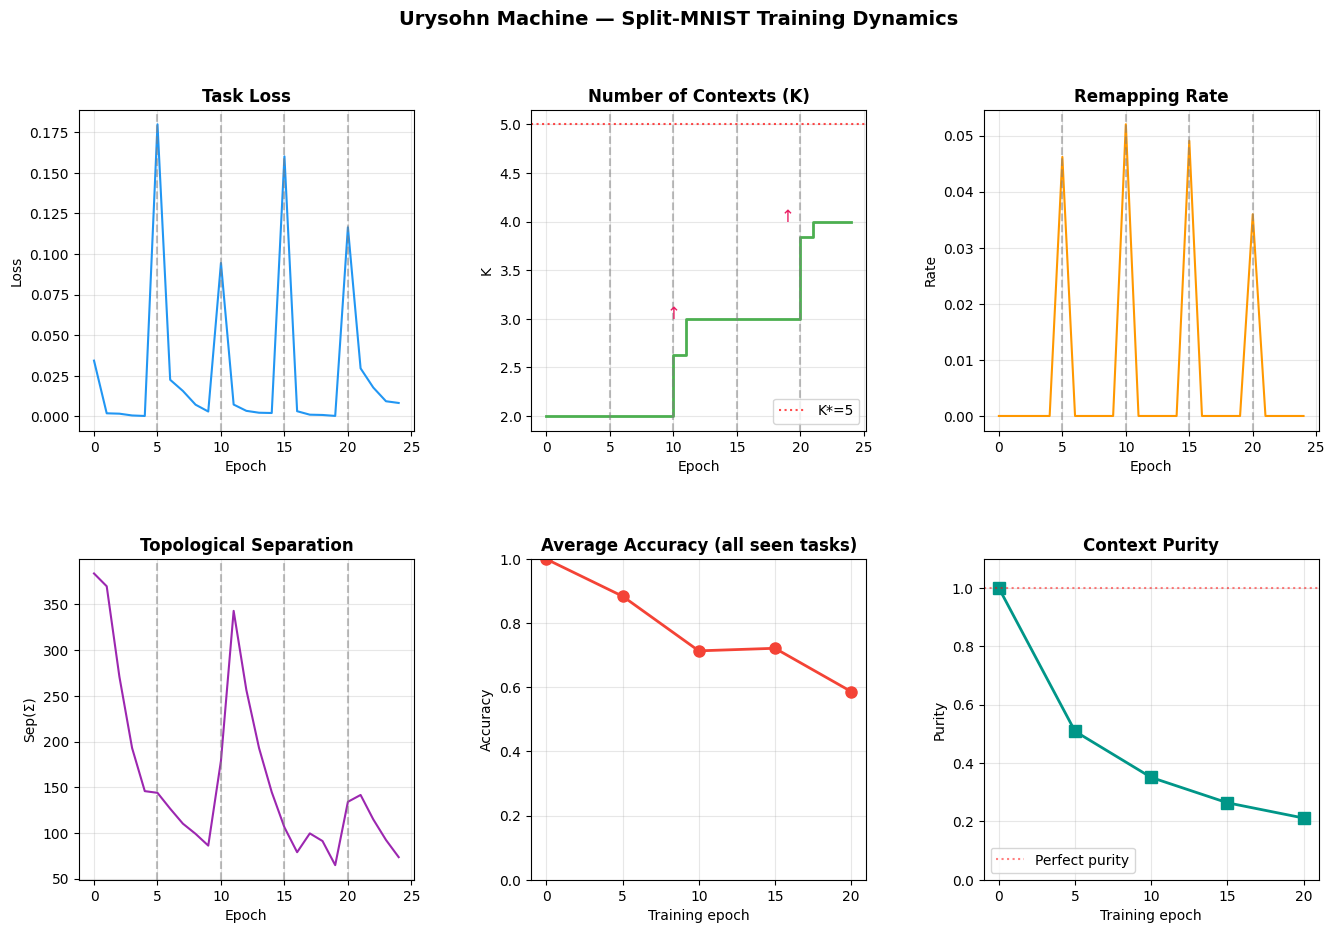

Figure saved to urysohn_training.png


In [ ]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # Task boundaries (vertical lines)
    task_boundaries = []
    steps_so_far = 0
    for t in range(N_TASKS):
        steps_so_far += EPOCHS_PER_TASK
        task_boundaries.append(steps_so_far)

    x_axis = list(range(len(history["task_loss"])))

    # 1. Task loss
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(x_axis, history["task_loss"], color="#2196F3", linewidth=1.5)
    for b in task_boundaries[:-1]: ax1.axvline(b, color="gray", linestyle="--", alpha=0.5)
    ax1.set_title("Task Loss", fontweight="bold"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.grid(alpha=0.3)

    # 2. Number of contexts
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(x_axis, history["n_contexts"], color="#4CAF50", linewidth=2, drawstyle="steps-post")
    for b in task_boundaries[:-1]: ax2.axvline(b, color="gray", linestyle="--", alpha=0.5)
    ax2.axhline(N_TASKS, color="red", linestyle=":", alpha=0.7, label=f"K*={N_TASKS}")
    for ev in split_events:
        step_idx = ev["step"] // (len(train_loaders[0]))
        ax2.annotate("↑", xy=(min(step_idx, len(x_axis)-1), ev["K"]),
                     fontsize=12, color="#E91E63", ha="center")
    ax2.set_title("Number of Contexts (K)", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("K"); ax2.legend(); ax2.grid(alpha=0.3)

    # 3. Remapping rate
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(x_axis, history["remap_rate"], color="#FF9800", linewidth=1.5)
    for b in task_boundaries[:-1]: ax3.axvline(b, color="gray", linestyle="--", alpha=0.5)
    ax3.set_title("Remapping Rate", fontweight="bold")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("Rate"); ax3.grid(alpha=0.3)

    # 4. Topological separation
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(x_axis, history["topo_separation"], color="#9C27B0", linewidth=1.5)
    for b in task_boundaries[:-1]: ax4.axvline(b, color="gray", linestyle="--", alpha=0.5)
    ax4.set_title("Topological Separation", fontweight="bold")
    ax4.set_xlabel("Epoch"); ax4.set_ylabel("Sep(Σ)"); ax4.grid(alpha=0.3)

    # 5. Average accuracy over time
    if history.get("avg_accuracy"):
        ax5 = fig.add_subplot(gs[1, 1])
        task_eval_x = list(range(0, N_TASKS * EPOCHS_PER_TASK, EPOCHS_PER_TASK))
        ax5.plot(task_eval_x, history["avg_accuracy"][:N_TASKS],
                 color="#F44336", linewidth=2, marker="o", markersize=8)
        ax5.set_title("Average Accuracy (all seen tasks)", fontweight="bold")
        ax5.set_xlabel("Training epoch"); ax5.set_ylabel("Accuracy"); ax5.grid(alpha=0.3)
        ax5.set_ylim(0, 1)

    # 6. Context purity over time
    if history.get("context_purity"):
        ax6 = fig.add_subplot(gs[1, 2])
        task_eval_x = list(range(0, N_TASKS * EPOCHS_PER_TASK, EPOCHS_PER_TASK))
        ax6.plot(task_eval_x, history["context_purity"][:N_TASKS],
                 color="#009688", linewidth=2, marker="s", markersize=8)
        ax6.axhline(1.0, color="red", linestyle=":", alpha=0.5, label="Perfect purity")
        ax6.set_title("Context Purity", fontweight="bold")
        ax6.set_xlabel("Training epoch"); ax6.set_ylabel("Purity"); ax6.legend()
        ax6.grid(alpha=0.3); ax6.set_ylim(0, 1.1)

    fig.suptitle("Urysohn Machine — Split-MNIST Training Dynamics", fontsize=14, fontweight="bold")
    plt.savefig("urysohn_training.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figure saved to urysohn_training.png")

except ImportError:
    print("matplotlib not available — skipping visualization")
    print("Run: !pip install matplotlib")


## 11. Probing the Indexer

The indexer's behavior can be examined directly: what contexts does it assign
to inputs from each task, and how pure are those assignments?

The key theoretical prediction: **context assignment should be stable within a task
and switch discretely at task boundaries** — not drift gradually.


In [ ]:
print("Context assignment analysis")
print("─" * 50)
print(f"{'Task':>6} | {'N samples':>10} | {'Dominant ctx':>13} | {'Purity':>8} | Distribution")
print("─" * 50)

for t in range(N_TASKS):
    all_ctx = []
    for x, y, _ in test_loaders[t]:
        ctx = machine.context_assignments(x.to(device)).cpu()
        all_ctx.append(ctx)
    all_ctx = torch.cat(all_ctx)
    counts = torch.bincount(all_ctx, minlength=config.indexer.max_contexts)
    active_counts = {c: counts[c].item() for c in machine.indexer.active_indices if counts[c] > 0}
    dom_ctx = max(active_counts, key=active_counts.get)
    total = sum(active_counts.values())
    purity = active_counts[dom_ctx] / total if total > 0 else 0
    dist_str = " ".join(f"c{c}:{n}" for c, n in sorted(active_counts.items()))
    print(f"  T{t} ({SplitMNIST.TASK_CLASSES[t]}) | {total:>10} | ctx {dom_ctx:>10} | {purity:>7.3f} | {dist_str}")

print()
print("Interpretation:")
print("  Purity → 1.0 = indexer cleanly separates tasks (topological separation achieved)")
print("  Purity ≈ 0.5 = two tasks sharing a context (insufficient splits)")
print(f"\nFinal K = {machine.indexer.n_active_contexts} (target K* = {N_TASKS})")


Context assignment analysis
──────────────────────────────────────────────────
  Task |  N samples |  Dominant ctx |   Purity | Distribution
──────────────────────────────────────────────────
  T0 ((0, 1)) |       2115 | ctx          0 |   1.000 | c0:2115
  T1 ((2, 3)) |       2042 | ctx          0 |   1.000 | c0:2042
  T2 ((4, 5)) |       1874 | ctx          0 |   1.000 | c0:1874
  T3 ((6, 7)) |       1986 | ctx          0 |   1.000 | c0:1986
  T4 ((8, 9)) |       1983 | ctx          0 |   1.000 | c0:1983

Interpretation:
  Purity → 1.0 = indexer cleanly separates tasks (topological separation achieved)
  Purity ≈ 0.5 = two tasks sharing a context (insufficient splits)

Final K = 4 (target K* = 5)


## 12. Further Experiments

Some experiments that would test the theoretical predictions:

### Ablation: disable structural decoupling
Set `lr_indexer = lr_metric` and allow task gradients to flow into the indexer.
The prediction: context purity degrades because the indexer optimizes for task
performance rather than topological separation.

### Permuted-MNIST
10 tasks with pixel permutations. The indexer should discover 10 contexts even
though all tasks share the same label space — detecting *geometric* novelty.

### Vary K*
Try `n_tasks=3` or `n_tasks=10` to test whether K converges to the correct K*.
The sample complexity bound predicts convergence time scales as O(β_max · K* · log(1/δ)).

### TDA upgrade
Install `ripser` and set `use_tda=True` to enable the full persistent homology
identification procedure. This should improve split precision (fewer false positives).


In [ ]:
# ── Ablation: Permuted-MNIST ─────────────────────────────────────────────────
# Uncomment to run Permuted-MNIST (10 tasks, shared label space, different geometry)

# N_TASKS_PERM = 10
# SEED = 42

# class PermutedMNISTSingle(Dataset):
#     def __init__(self, task_id, n_tasks=10, data_dir="./data", train=True, seed=42):
#         transform = transforms.Compose([transforms.ToTensor(),
#             transforms.Normalize((0.1307,),(0.3081,)),
#             transforms.Lambda(lambda x: x.view(-1))])
#         self.base = torchvision.datasets.MNIST(data_dir, train=train, download=True, transform=transform)
#         rng = np.random.RandomState(seed)
#         perms = [np.arange(784)] + [rng.permutation(784) for _ in range(n_tasks-1)]
#         self.perm = torch.tensor(perms[task_id], dtype=torch.long)
#         self.task_id = task_id
#     def __len__(self): return len(self.base)
#     def __getitem__(self, i):
#         x, y = self.base[i]; return x[self.perm], y, self.task_id

# perm_config = UrysohnConfig(
#     indexer=IndexerConfig(input_dim=784, output_dim=10, init_contexts=2, max_contexts=30),
#     metric=MetricLearnerConfig(input_dim=784, output_dim=10),
#     ...
# )
# Run training as above with PermutedMNISTSingle loaders

print("Notebook complete.")
print()
print("Key results to report:")
print(f"  Final K: {machine.indexer.n_active_contexts} / K*={N_TASKS}")
print(f"  Split events: {len(split_events)}")
print(f"  Final avg accuracy: {np.mean(list(final_accs.values())):.4f}")
print(f"  Final context purity: {final_purity:.4f}")


Notebook complete.

Key results to report:
  Final K: 4 / K*=5
  Split events: 2
  Final avg accuracy: 0.5872
  Final context purity: 0.2115
